In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df=pd.read_csv("../data/cdm_transactions.csv")
df.head()

,TransactionID,Time,Account Number,Card Number,Transaction Type,Channel,Transaction Amount,Merchand Group,Country,Country2,...,Merchand Code,ClientID,ClientProfile,ClientSegment,ClientSalaryMAD,IsWeekend,TransactionHour,IsInternational,IsAnomaly,AnomalyType
0,MON202501010108625,2025-01-01 19:46:38,3029680169,4.376546e+15,PAIEMENT MOBILE,WEB,546.68,CAFE,MA,MA,...,CAF_SET_473,CDM-000445,domestic_only,MIDDLE,11480,0,19,0,0,normal
1,MON202501010108624,2025-01-01 20:26:33,3029680169,4.376546e+15,VIREMENT,TPE,481.79,HOTEL,MA,MA,...,HOT_SET_384,CDM-000445,domestic_only,MIDDLE,11480,0,20,0,0,normal
2,MON202501030108626,2025-01-03 17:17:29,3029680169,4.376546e+15,RETRAIT GAB,ATM,375.40,STATION,MA,MA,...,STA_NAD_831,CDM-000445,domestic_only,MIDDLE,11480,0,17,0,0,normal
3,MON202501040108627,2025-01-04 09:43:11,3029680169,4.376546e+15,PAIEMENT MOBILE,TPE,1354.04,SUPERMARCHE,MA,MA,...,SUP_SAF_411,CDM-000445,domestic_only,MIDDLE,11480,1,9,0,0,normal
4,INT202501040108628,2025-01-04 22:01:15,3029680169,4.376546e+15,PAIEMENT MOBILE,MOBILE,684.11,LUXURY,MA,MA,...,LUX_SET_850,CDM-000445,domestic_only,MIDDLE,11480,1,22,0,0,normal


In [3]:
df.columns

Index(['TransactionID', 'Time', 'Account Number', 'Card Number',
       'Transaction Type', 'Channel', 'Transaction Amount', 'Merchand Group',
       'Country', 'Country2', 'City2', 'Card Type', 'Age', 'Gender', 'Bank',
       'City', 'Merchand Code', 'ClientID', 'ClientProfile', 'ClientSegment',
       'ClientSalaryMAD', 'IsWeekend', 'TransactionHour', 'IsInternational',
       'IsAnomaly', 'AnomalyType'],
      dtype='object')

In [4]:
df.shape

(100000, 26)

In [5]:
idcols=["TransactionID","Account Number","Card Number","Merchand Code","Client ID"]

In [6]:
numcols=["Transaction Amount","Age",]

In [7]:
catcols=["Transaction Type","Channel","Card Type","Gender","Merchand Group","Country","City","Country 2","City 2"]

In [8]:
df.dropna(inplace=True)

In [9]:
df['Time']=pd.to_datetime(df['Time'])
df['Age']=df['Age'].astype(int)

In [10]:
df['hour']=df['Time'].dt.hour
df['date']=df['Time'].dt.date
df['LogAmount']=np.log(df['Transaction Amount'])

In [11]:
# sampledf=df.sample(n=100000,random_state=40)
# sampledf.to_csv("sampledata.csv")

In [12]:
sampledf=df

# Univariate Analysis

In [13]:
#Numeric Features
df[['Age','Transaction Amount',"LogAmount"]].describe()

,Age,Transaction Amount,LogAmount
count,100000.000000,100000.000000,100000.000000
mean,47.719110,9118.592043,7.578327
std,15.151733,19706.145524,1.811550
min,20.000000,5.060000,1.621366
25%,36.000000,648.027500,6.473933
50%,48.000000,1437.935000,7.270963
75%,60.000000,6805.812500,8.825532
max,75.000000,991275.850000,13.806748


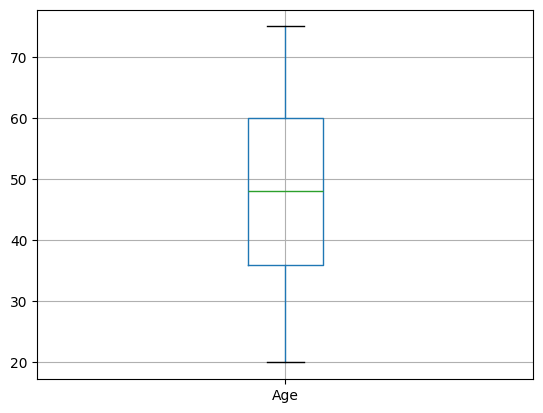

In [14]:
sampledf.boxplot("Age")
plt.show()

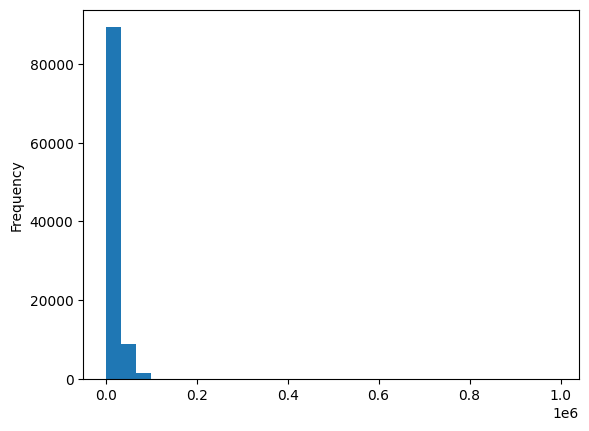

In [15]:
sampledf['Transaction Amount'].plot(kind='hist',bins=30)
plt.show()

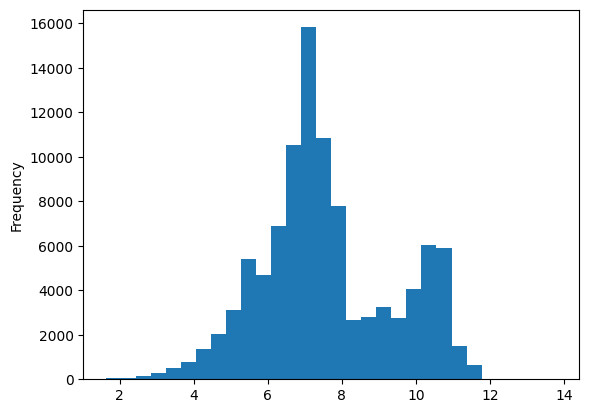

In [16]:
sampledf['LogAmount'].plot(kind='hist',bins=30)
plt.show()

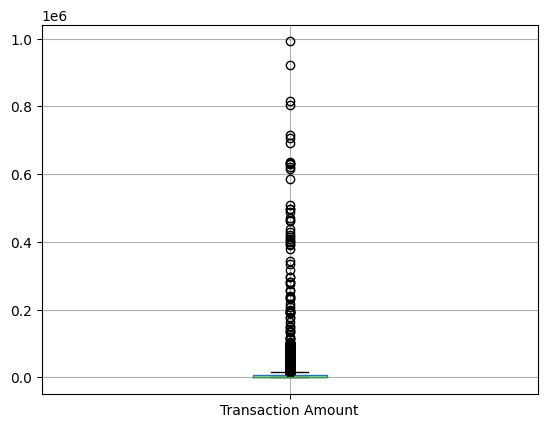

In [17]:
sampledf.boxplot("Transaction Amount")
plt.show()

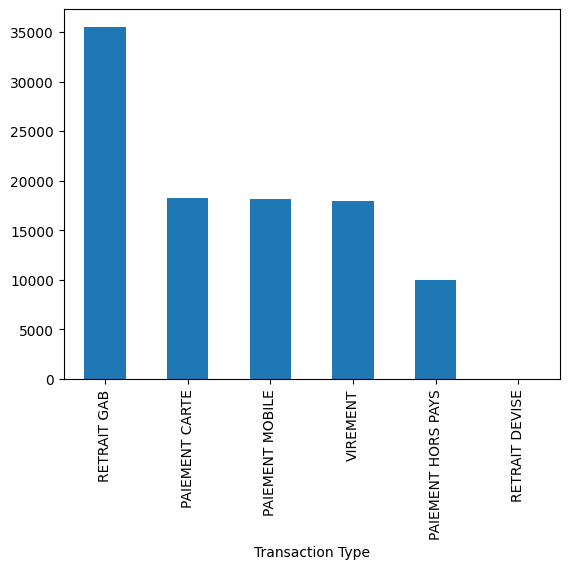

In [18]:
#Categorical Features
sampledf['Transaction Type'].value_counts().plot(kind='bar')
plt.show()

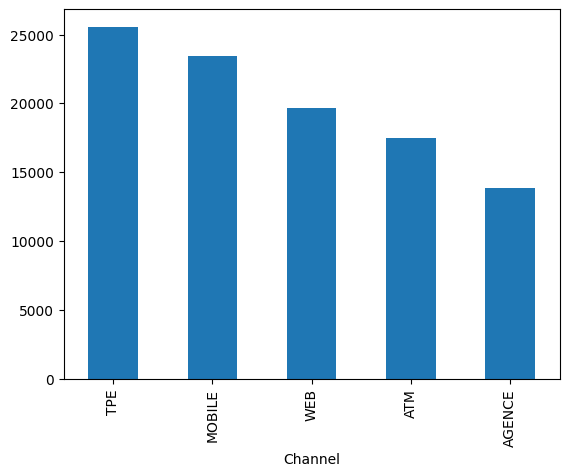

In [19]:
sampledf['Channel'].value_counts().plot(kind='bar')
plt.show()

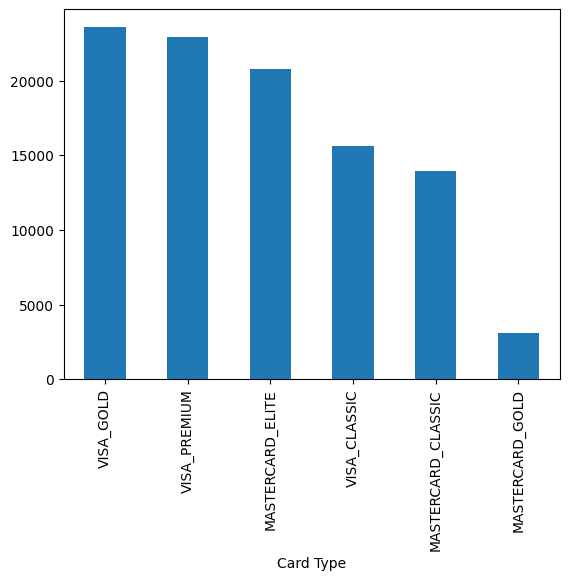

In [20]:
sampledf['Card Type'].value_counts().plot(kind='bar')
plt.show()

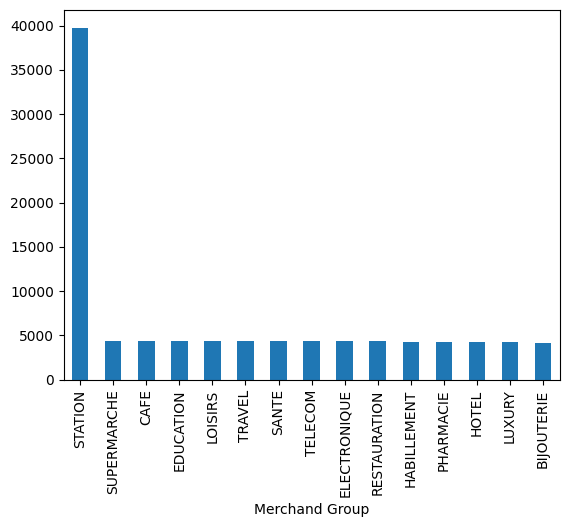

In [21]:
sampledf['Merchand Group'].value_counts().plot(kind='bar')
plt.show()

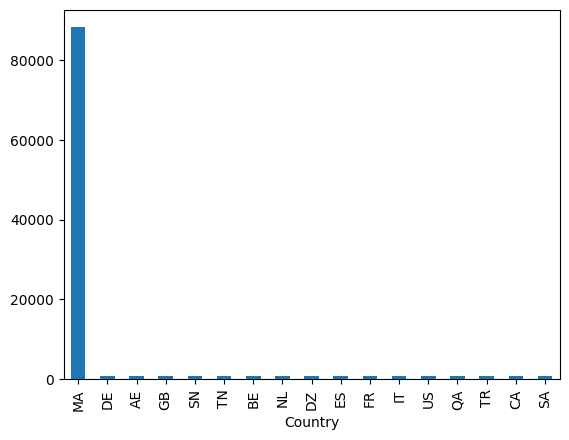

In [22]:
sampledf['Country'].value_counts().plot(kind='bar')
plt.show()

# Client Behavior Analysis

In [25]:
#sampling different type of clients to analyze normal behavior
activity=df.groupby("Account Number").size()
cltactivity=activity.to_frame("activity")
cltactivity["bucket"]=pd.qcut(
    cltactivity['activity'],
    q=[0,0.33,0.66,1],
    labels=['low','medium','high']
)

In [26]:
sampledclt=cltactivity.groupby("bucket",group_keys=False).apply(lambda x: x.sample(n=min(len(x),5),random_state=42))
sampledclt=sampledclt.index

sampledf=df[df['Account Number'].isin(sampledclt)]
sampledf.shape

/tmp/ipykernel_4810/2444936049.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  sampledclt=cltactivity.groupby("bucket",group_keys=False).apply(lambda x: x.sample(n=min(len(x),5),random_state=42))
/tmp/ipykernel_4810/2444936049.py:1: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  sampledclt=cltactivity.groupby("bucket",group_keys=False).apply(lambda x: x.sample(n=min(len(x),5),random_state=42))


(4050, 29)

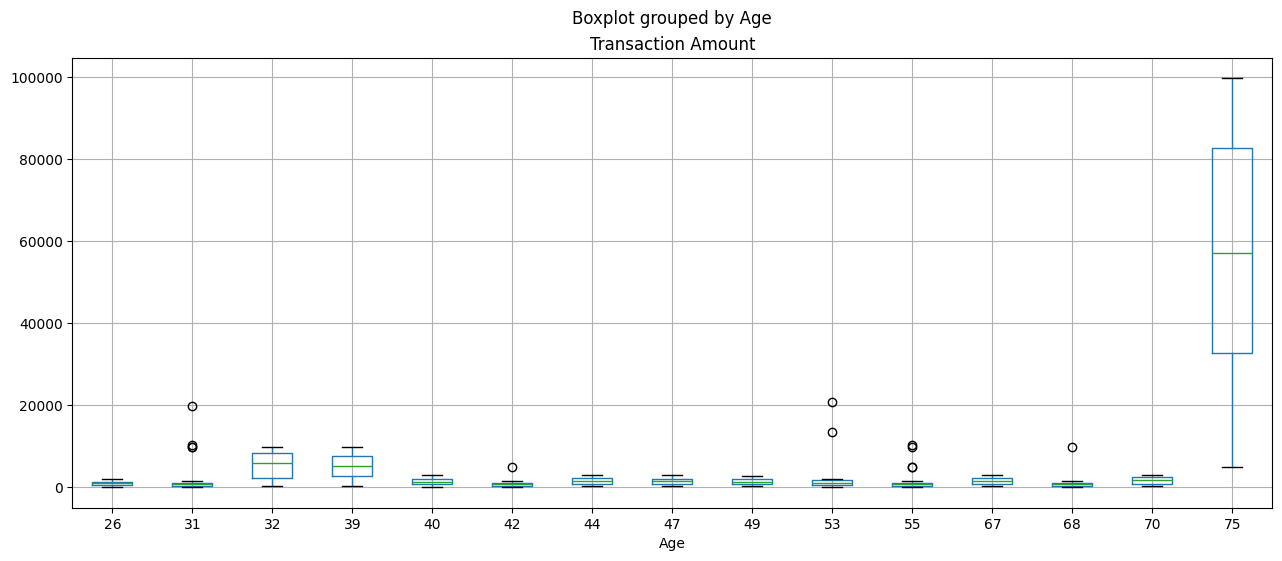

In [27]:
sampledf.boxplot("Transaction Amount",by='Age',figsize=(15,6))
plt.show()

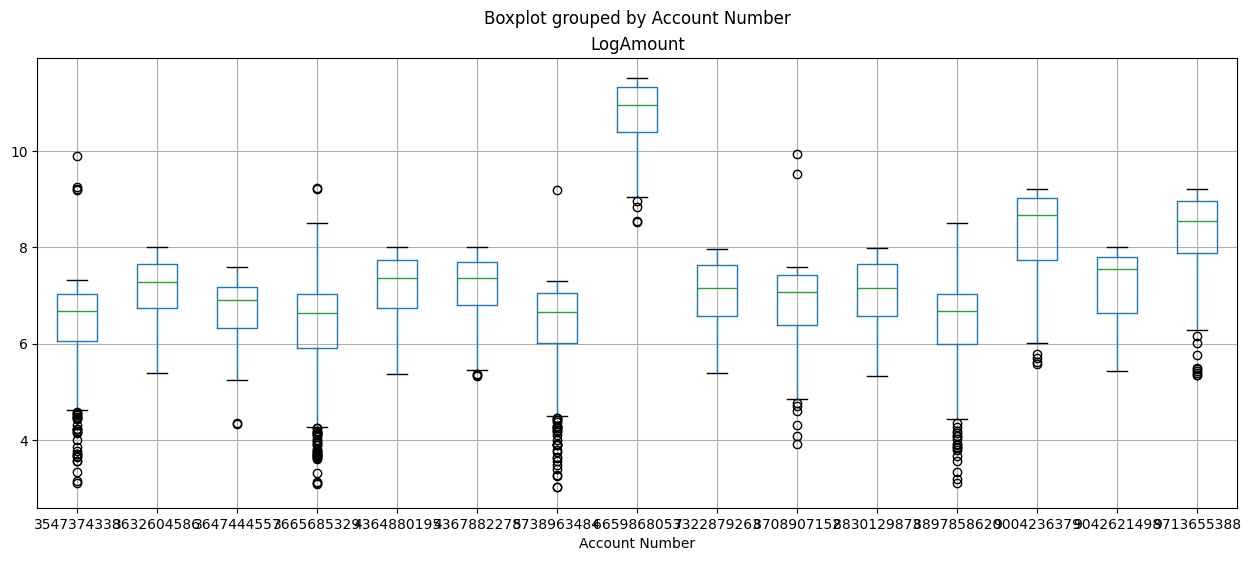

In [28]:
sampledf.boxplot("LogAmount",by='Account Number',figsize=(15,6))
plt.show()

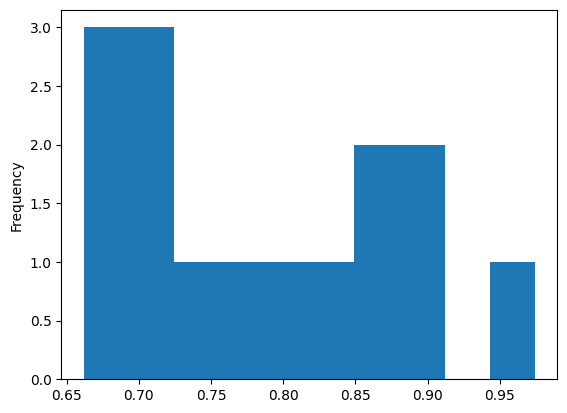

In [29]:
cltstats=sampledf.groupby("Account Number").agg({"LogAmount":['count','mean','std'],
                                        "Transaction Amount":['count','mean','std']})

cltstats[("LogAmount","std")].plot(kind='hist')
plt.show()

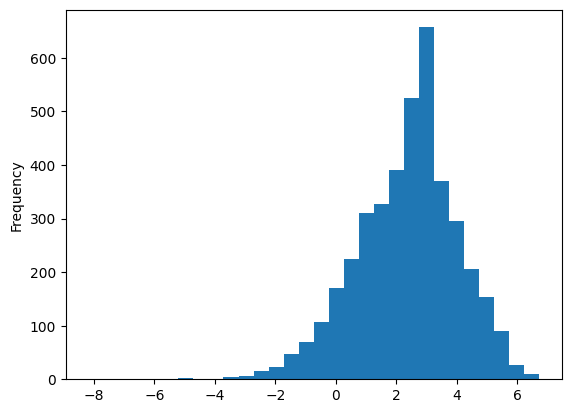

In [30]:
timedf=sampledf[['Time','date','Account Number','Transaction Amount','LogAmount']].sort_values(['Account Number','Time'])
timedf['TimeDiff']=timedf.groupby("Account Number")['Time'].diff().dt.total_seconds()/3600
timedf['LogTimeDiff']=np.log(timedf['TimeDiff'])
timedf['LogTimeDiff'].plot(kind='hist',bins=30)
plt.show()


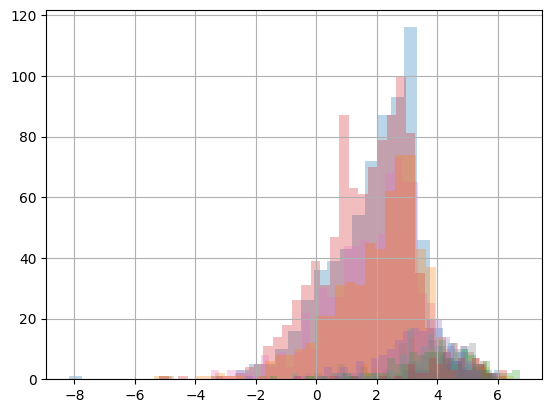

In [31]:
for acc, dfacc in timedf.groupby("Account Number"):
    dfacc['LogTimeDiff'].hist(bins=30,alpha=0.3)

plt.show()

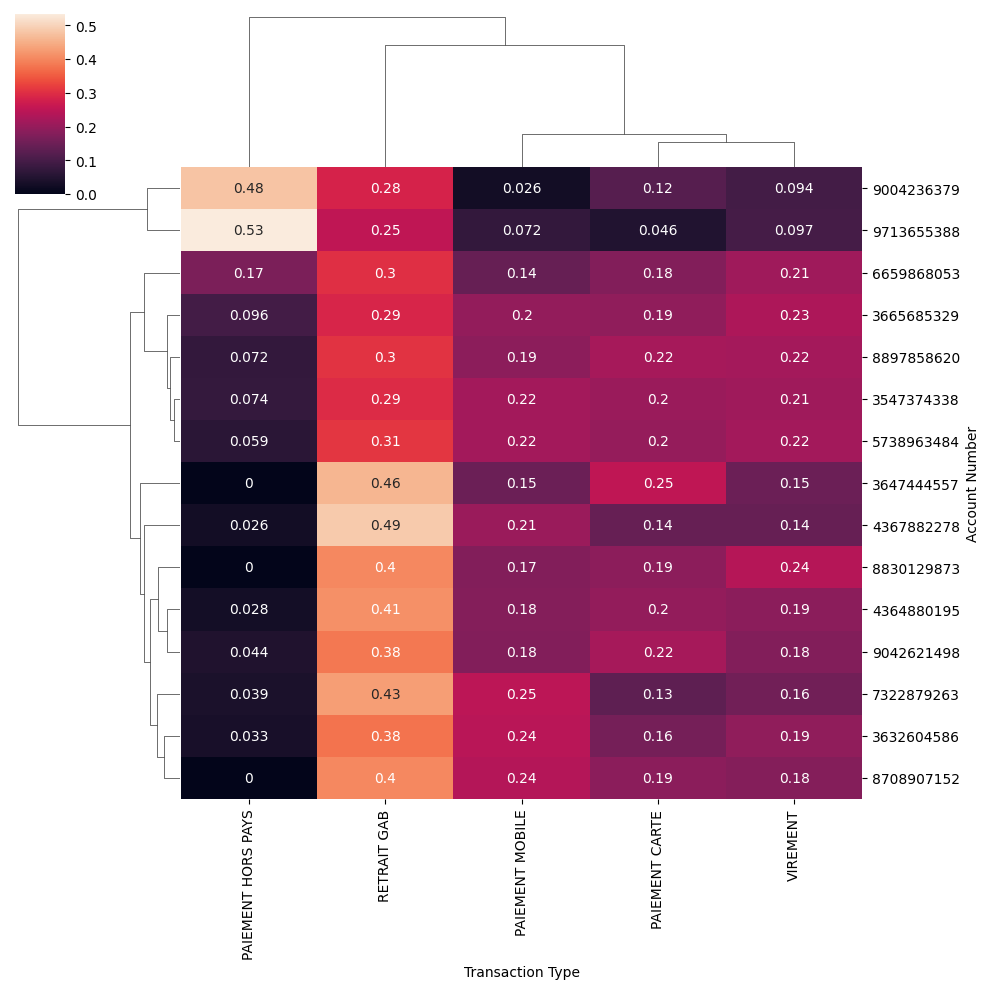

In [32]:
ct=pd.crosstab(
    sampledf['Account Number'],
    [sampledf['Transaction Type']],
    normalize='index'
)

sns.clustermap(ct,annot=True)
plt.show()

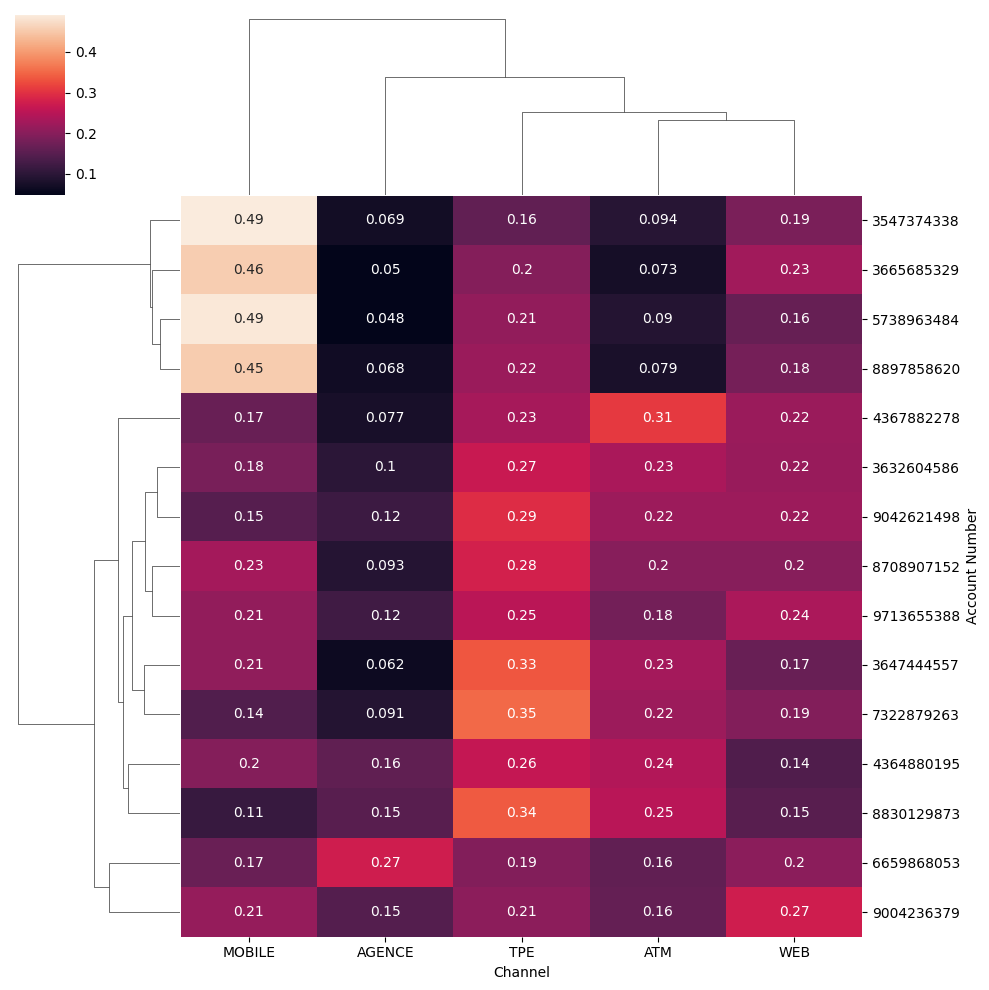

In [33]:
ct=pd.crosstab(
    sampledf['Account Number'],
    [sampledf['Channel']],
    normalize='index'
)

sns.clustermap(ct,annot=True)
plt.show()

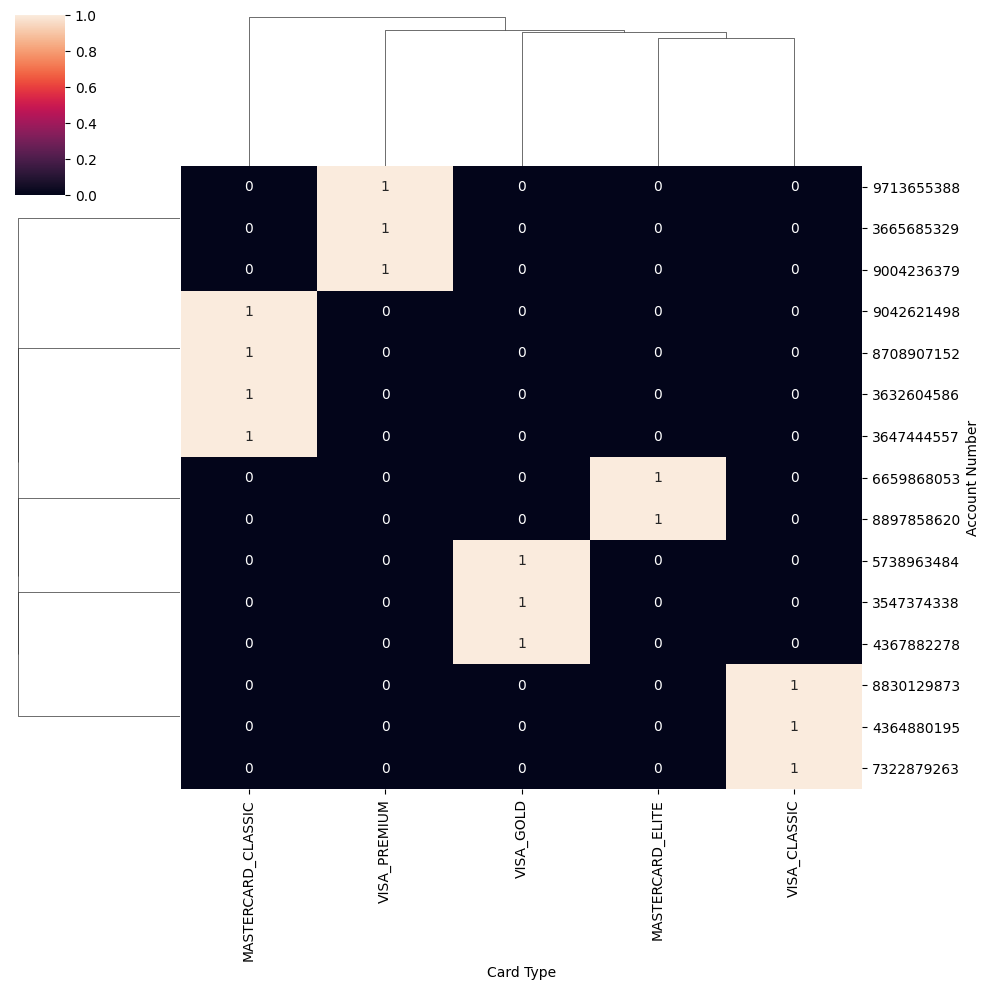

In [34]:
ct=pd.crosstab(
    sampledf['Account Number'],
    [sampledf['Card Type']],
    normalize='index'
)

sns.clustermap(ct,annot=True)
plt.show()

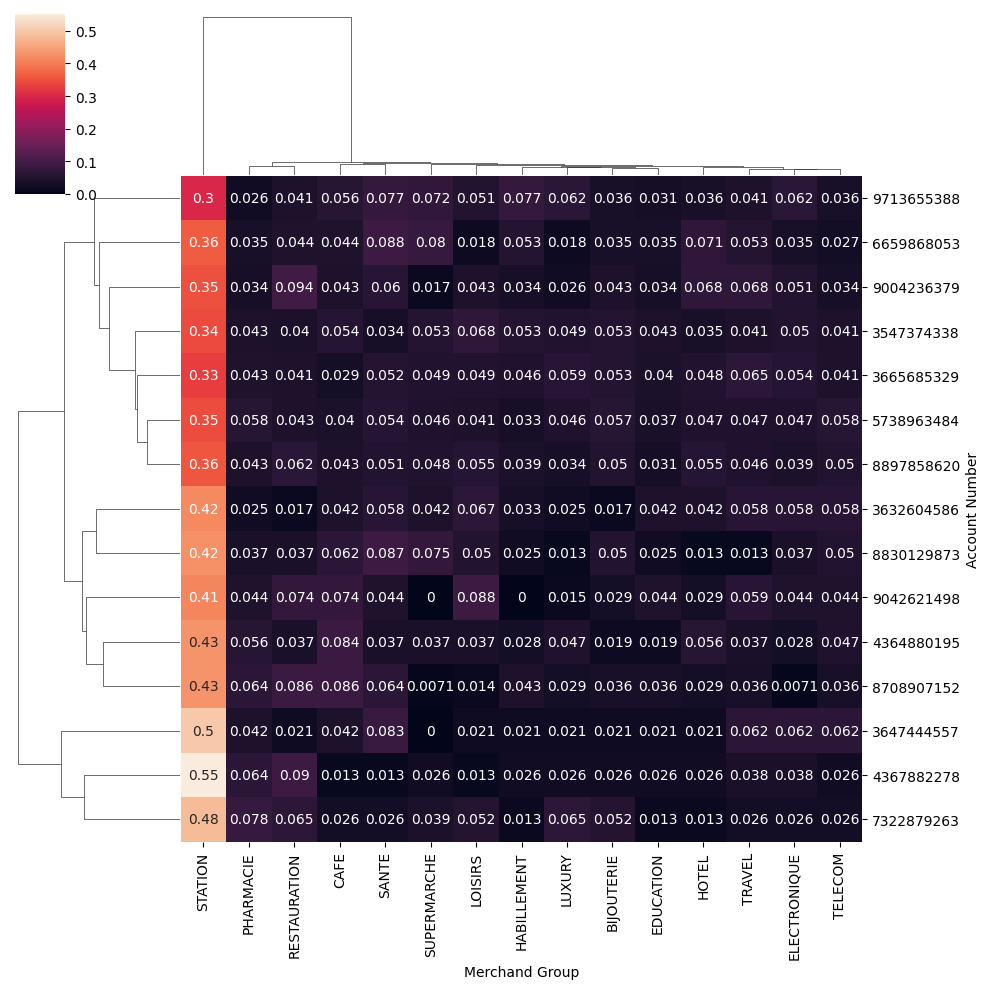

In [35]:
ct=pd.crosstab(
    sampledf['Account Number'],
    [sampledf['Merchand Group']],
    normalize='index'
)

sns.clustermap(ct,annot=True)
plt.show()

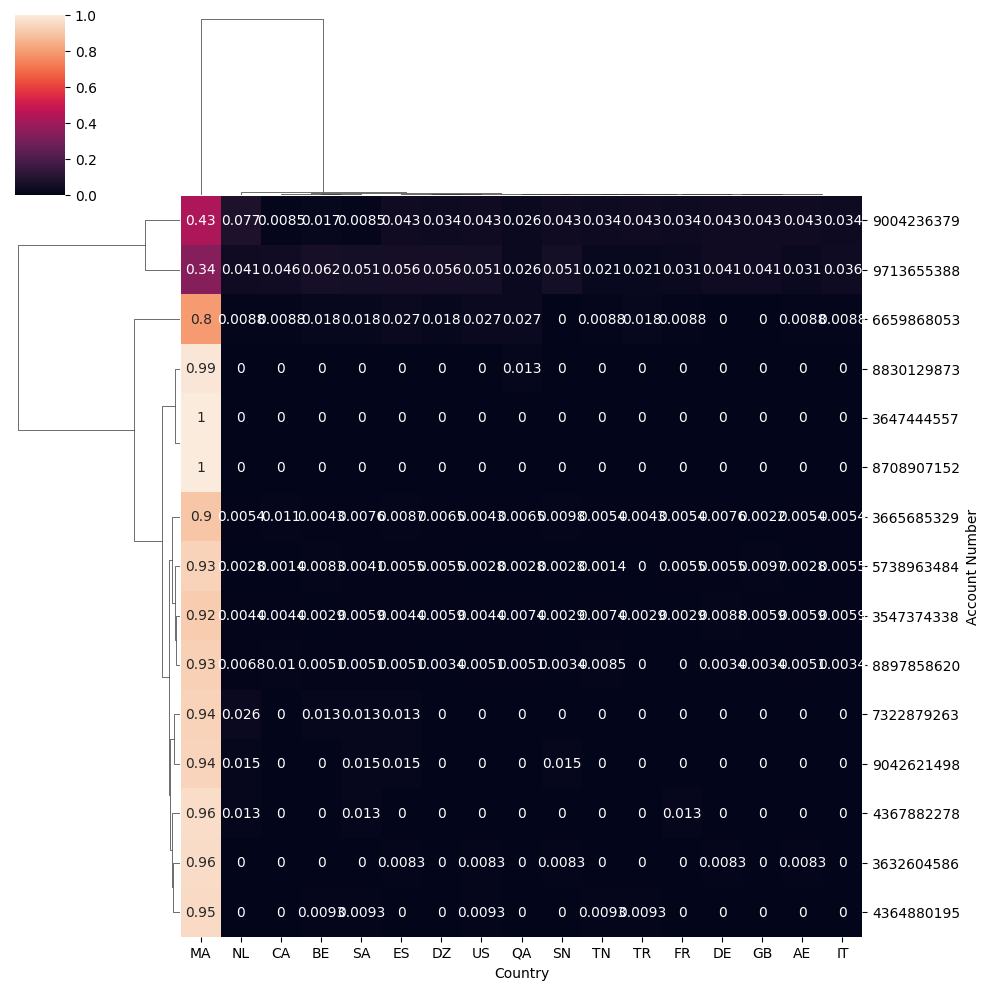

In [36]:
ct=pd.crosstab(
    sampledf['Account Number'],
    [sampledf['Country']],
    normalize='index'
)

sns.clustermap(ct,annot=True)
plt.show()

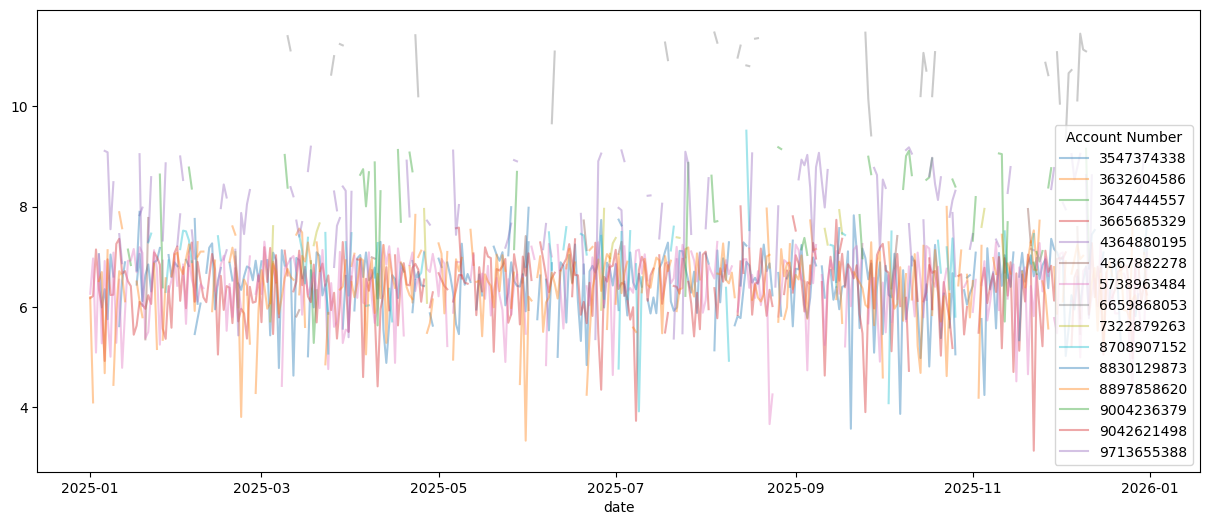

In [37]:
daily = sampledf.groupby(["Account Number", "date"])["LogAmount"].mean().reset_index()

pivot_daily = daily.pivot(index="date", columns="Account Number", values="LogAmount")

pivot_daily.plot(figsize=(15,6),alpha=0.4)
plt.show()

# Feature Engineering

In [ ]:
df.sort_values(['Account Number','Time'],inplace=True)
df['MovingAvg']=df['LogAmount'].rolling(window=7).mean()
df['MovingAvg']=df['LogAmount'].rolling(window=7).std()

In [ ]:
df['TimeDiff']=df.groupby("Account Number")['Time'].diff().dt.total_seconds()/3600
df['LogTimeDiff']=np.log(df['TimeDiff'])

/home/aymanfen/Desktop/RealTimeFraudDetection/.venv/lib/python3.13/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


In [ ]:
def entropy(series):
    p=series.value_counts(normalize=True)
    return -(p * np.log(p)).sum()

In [ ]:
def normalentropy(series):
    p=series.value_counts(normalize=True)
    h=-(p*np.log(p)).sum()
    return h/np.log(len(p)) if len(p) > 1 else 0

In [ ]:
transactiontypeentropy=df.groupby("Account Number")['Transaction Type'].apply( normalentropy ).reset_index(name="TransactionTypeEntropy")
channelentropy=df.groupby("Account Number")['Channel'].apply( normalentropy ).reset_index(name="ChannelEntropy")
cardtypeentropy=df.groupby("Account Number")['Card Type'].apply( normalentropy ).reset_index(name="CardTypeEntropy")
merchandentropy=df.groupby("Account Number")['Merchand Group'].apply( normalentropy ).reset_index(name="MerchandEntropy")
countryentropy=df.groupby("Account Number")['Country'].apply( normalentropy ).reset_index(name="CountryEntropy")
cityentropy=df.groupby("Account Number")['City'].apply( normalentropy ).reset_index(name="CityEntropy")

In [ ]:
finaldf=df.merge(transactiontypeentropy,on='Account Number',how='left')
finaldf=finaldf.merge(channelentropy,on='Account Number',how='left')
finaldf=finaldf.merge(cardtypeentropy,on='Account Number',how='left')
finaldf=finaldf.merge(merchandentropy,on='Account Number',how='left')
finaldf=finaldf.merge(countryentropy,on='Account Number',how='left')
finaldf=finaldf.merge(cityentropy,on='Account Number',how='left')